In [1]:
import pandas as pd
import json
from mbiomekit.group_comparison import analysis, plotter


Analysis group: ['c0', 'c2', 'c3']
Number of all shared members: 5
Number of c0 specific members: 20
Number of c2 specific members: 16
Number of c3 specific members: 13


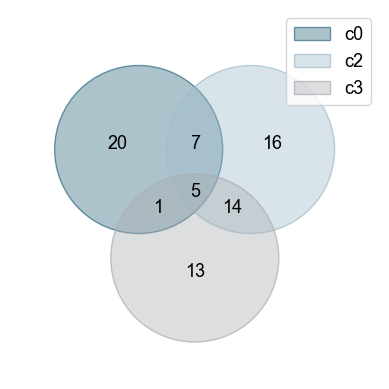

In [2]:
# comaprionon across enterotype
ca = analysis.ComparativeAnalyzer()
for c in [0, 1, 2, 3]:
    ca.load_kruskal_wallis_dunn_result(f'c{c}', f'data/3-results/group_comparison/kruskal_cl{c}_genus.tsv', f'data/3-results/group_comparison/dunn_cl{c}_genus.json')
ca.filter_by_significance()
ca.evaluate_common_and_specific_group(grps=['c0', 'c2', 'c3'], fout='data/3-results/group_comparison/shared_specific_three_groups.json', fout_venn='figures/group_comparison/venn3.pdf', venn_cmap={'c0': '#326a81ff', 'c2': '#9fbccaff', 'c3': '#aaadb2ff'})

Analysis group: ['c0', 'c1', 'c2', 'c3']
Number of all shared members: 1
Number of c0 specific members: 20
Number of c1 specific members: 3
Number of c2 specific members: 16
Number of c3 specific members: 12


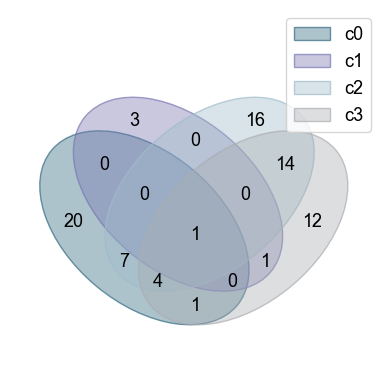

In [3]:
# comaprionon across enterotype
ca = analysis.ComparativeAnalyzer()
for c in [0, 1, 2, 3]:
    ca.load_kruskal_wallis_dunn_result(f'c{c}', f'data/3-results/group_comparison/kruskal_cl{c}_genus.tsv', f'data/3-results/group_comparison/dunn_cl{c}_genus.json')
ca.filter_by_significance()
ca.evaluate_common_and_specific_group(grps=['c0', 'c1', 'c2', 'c3'], fout='data/3-results/group_comparison/shared_specific.json', fout_venn='figures/group_comparison/venn4.pdf', venn_cmap={'c0': '#326a81ff', 'c1': '#7876b1c0', 'c2': '#9fbccaff', 'c3': '#aaadb2ff'})    

In [4]:
# load result
with open('data/3-results/group_comparison/shared_specific_three_groups.json', 'r') as file:
    rs3 = json.load(file)

with open('data/3-results/group_comparison/shared_specific.json', 'r') as file:
    rs4 = json.load(file)

print(rs3['shared_members'])

# plot common 
ft = pd.read_csv('data/ft_genus_prv01.tsv', sep='\t', header=0, index_col=0)

group = pd.read_csv('data/group.tsv', sep='\t', header=0, index_col=0)

grp_map = {}
for sid, g in group['group1'].items():
    grp_map[sid] = g

# enterotype
ent = pd.read_csv('data/enterotype.tsv', sep='\t', header=0, index_col=0)
id_c0 = ent.index[ent['cluster'] == 0]
id_c1 = ent.index[ent['cluster'] == 1]
id_c2 = ent.index[ent['cluster'] == 2]
id_c3 = ent.index[ent['cluster'] == 3]
ids = {0: id_c0,
       1: id_c1,
       2: id_c2,
       3: id_c3}


['g__Eubacterium_R', 'g__Lachnoclostridium_B', 'g__Lentihominibacter', 'g__Hominiventricola', 'g__Evtepia']


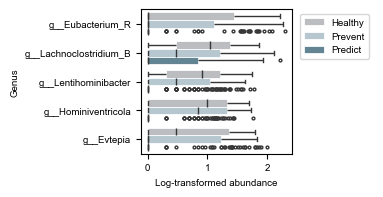

In [5]:
palette = {'Healthy': '#aaadb2',
           'Prevent': '#9fbcca',
           'Predict': '#326a81'}

p = plotter.Plotter()
p.plot_microbe_abundance(ft.loc[rs3['shared_members'], :], fout='figures/group_comparison/shared.pdf', palette=palette, group_map=grp_map, label='Genus', hue_order=['Healthy', 'Prevent', 'Predict'])


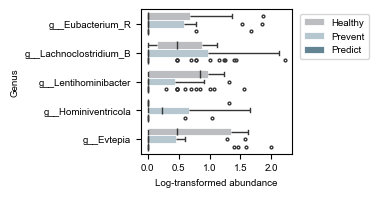

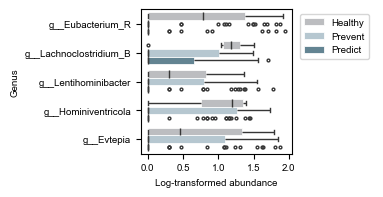

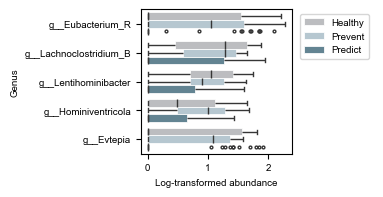

In [6]:
p = plotter.Plotter()
p.plot_microbe_abundance(ft.loc[rs3['shared_members'], ids[0]], palette=palette, group_map=grp_map, label='Genus', hue_order=['Healthy', 'Prevent', 'Predict'])

p = plotter.Plotter()
p.plot_microbe_abundance(ft.loc[rs3['shared_members'], ids[2]], palette=palette, group_map=grp_map, label='Genus', hue_order=['Healthy', 'Prevent', 'Predict'])

p = plotter.Plotter()
p.plot_microbe_abundance(ft.loc[rs3['shared_members'], ids[3]], palette=palette, group_map=grp_map, label='Genus', hue_order=['Healthy', 'Prevent', 'Predict'])



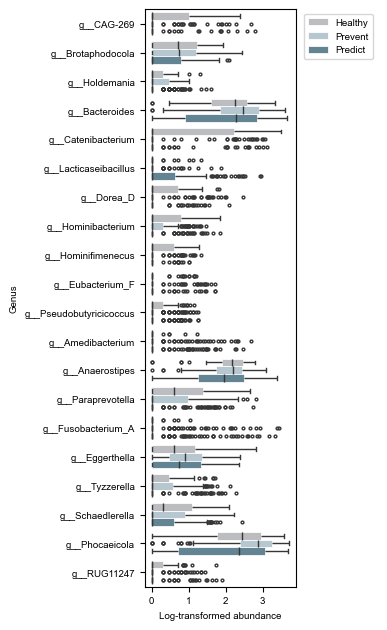

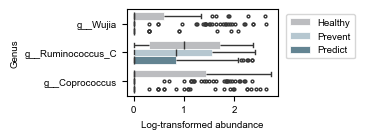

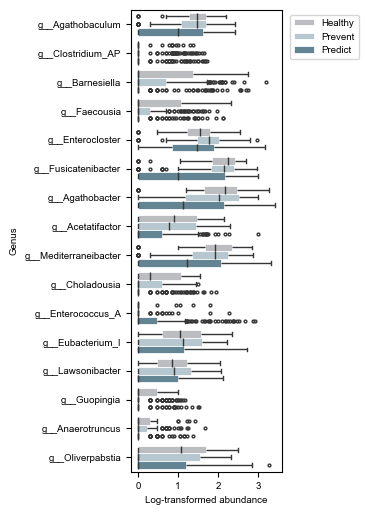

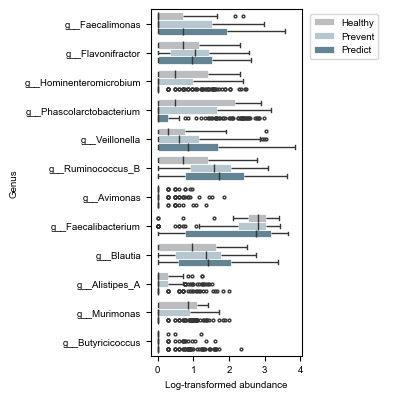

In [7]:
p = plotter.Plotter()
p.plot_microbe_abundance(ft.loc[rs4['specific_members']['c0'], :], fout='figures/group_comparison/specific_c0.pdf', palette=palette, group_map=grp_map, label='Genus', hue_order=['Healthy', 'Prevent', 'Predict'])

p = plotter.Plotter()
p.plot_microbe_abundance(ft.loc[rs4['specific_members']['c1'], :], fout='figures/group_comparison/specific_c1.pdf', palette=palette, group_map=grp_map, label='Genus', hue_order=['Healthy', 'Prevent', 'Predict'])

p = plotter.Plotter()
p.plot_microbe_abundance(ft.loc[rs4['specific_members']['c2'], :], fout='figures/group_comparison/specific_c2.pdf', palette=palette, group_map=grp_map, label='Genus', hue_order=['Healthy', 'Prevent', 'Predict'])

p = plotter.Plotter()
p.plot_microbe_abundance(ft.loc[rs4['specific_members']['c3'], :], fout='figures/group_comparison/specific_c3.pdf', palette=palette, group_map=grp_map, label='Genus', hue_order=['Healthy', 'Prevent', 'Predict'])